# 🧠 ¿Podemos predecir la carga cognitiva con regresión logística?



**Autores:**
- Miguel David Dávila Palomino
- Diego Santiago Yáñez Chile
- María Fernanda Zárate Prado

*Redes:* [@neuropucp](https://www.instagram.com/neuropucp)

---

## Introducción


-  **¿podemos estimar el estado mental de una persona a partir de su desempeño conductual?**
- Por ejemplo, cuando alguien realiza una tarea de memoria de trabajo, su tiempo de reacción, sus errores y su precisión podrían darnos pistas sobre cuánta "carga cognitiva" está experimentando.

En esta actividad vamos a entrenar un modelo de **machine learning** llamado **regresión logística** que intentará clasificar a participantes ficticios en dos grupos:

- **0 = baja carga cognitiva**
- **1 = alta carga cognitiva**

---

## 🧪 Caso psicológico ficticio

> Un laboratorio de psicología cognitiva quiere estudiar si ciertas variables conductuales y personales pueden ayudar a estimar si una persona está experimentando **alta carga cognitiva** mientras realiza una tarea de memoria de trabajo.

Las variables que registran son:

| Variable | Qué representa |
|---|---|
| `tiempo_reaccion_ms` | Tiempo promedio de reacción (en milisegundos) |
| `errores` | Cantidad de errores cometidos en la tarea |
| `horas_sueno` | Horas dormidas la noche anterior |
| `estres_percibido` | Estrés autoinformado (escala 1–10) |
| `precision` | Porcentaje de respuestas correctas (0–100) |
| `carga_cognitiva` | **Variable objetivo**: 0 = baja, 1 = alta |


---

## 🔍 ¿Qué es clasificación binaria?

A diferencia de la regresión lineal, que predice valores numéricos continuos (por ejemplo, "este estudiante obtendrá 7.4 en el examen"), la clasificación binaria asigna cada caso a una de dos categorías posibles:

- 📧 spam / no spam
- ✅ respuesta correcta / incorrecta
- 🧠 alta carga cognitiva / baja carga cognitiva
- 🔬 presencia / ausencia de una condición experimental


---

## ❓ ¿Por qué no usamos regresión lineal?

La regresión lineal predice **cualquier número real**: puede dar resultados como `-0.4`, `1.7` o `25.3`. Pero nosotros queremos una **probabilidad**, que solo puede estar entre **0 y 1** (o entre 0% y 100%).

Si usáramos regresión lineal directamente para predecir 0 o 1, nos toparíamos con valores imposibles de interpretar como probabilidad.

La **regresión logística** soluciona esto pasando el resultado por una función especial llamada **sigmoide**, que comprime cualquier número al rango **[0, 1]**.

> 🧭 **Analogía:** la sigmoide es como una "máquina traductora" que toma un número cualquiera (positivo, negativo, grande, pequeño) y lo convierte en una probabilidad entre 0% y 100%.

---

## 📐 La función sigmoide

Antes de la fórmula, la intuición:

- Si el modelo está **muy seguro de la clase 0**, la probabilidad se acerca a **0**.
- Si el modelo está **muy seguro de la clase 1**, la probabilidad se acerca a **1**.
- Si está **indeciso**, la probabilidad se acerca a **0.5**.

La fórmula es:


$$ g(z) = \frac{1}{1 + e^{-z}} $$

Donde:
- `z` es una combinación lineal de las variables de entrada (algo como `z = b0 + b1*x1 + b2*x2 + ...`).
- `e` es la constante de Euler (≈ 2.718).
- El resultado `g(z)` siempre estará entre 0 y 1.




## 🛠  1. Creación el dataset ficticio

Vamos a generar **350 participantes ficticios**.

La lógica que usaremos para generar la etiqueta es:

- más tiempo de reacción → mayor probabilidad de alta carga;
- más errores → mayor probabilidad de alta carga;
- más estrés → mayor probabilidad de alta carga;
- menos sueño → mayor probabilidad de alta carga;
- menor precisión → mayor probabilidad
de alta carga.

Añadimos **ruido aleatorio** para que el dataset no sea perfecto (como en la vida real).

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [ ]:
# Fijamos una semilla para que los resultados sean reproducibles
np.random.seed(42)

# Número de observaciones ficticias
n = 350

# Creamos variables ficticias
tiempo_reaccion_ms = np.random.normal(loc=650, scale=120, size=n)
errores = np.random.poisson(lam=6, size=n)
horas_sueno = np.random.normal(loc=6.5, scale=1.3, size=n)
estres_percibido = np.random.randint(1, 11, size=n)
precision = np.random.normal(loc=75, scale=12, size=n)

# Ajustamos límites razonables
tiempo_reaccion_ms = np.clip(tiempo_reaccion_ms, 300, 1100)
horas_sueno = np.clip(horas_sueno, 2, 10)
precision = np.clip(precision, 30, 100)
errores = np.clip(errores, 0, 20)

# Creamos una puntuación interna ficticia.
# La lógica es:
# - más tiempo, errores y estrés aumentan la carga
# - más sueño y precisión reducen la carga
z = (
    0.006 * (tiempo_reaccion_ms - 650)
    + 0.35 * (errores - 6)
    - 0.55 * (horas_sueno - 6.5)
    + 0.35 * (estres_percibido - 5)
    - 0.06 * (precision - 75)
)

# Agregamos ruido para que el dataset no sea demasiado perfecto
ruido = np.random.normal(0, 0.8, size=n)
z = z + ruido

# Convertimos la puntuación interna en probabilidad usando sigmoide
probabilidad_alta_carga = 1 / (1 + np.exp(-z))

# Generamos la clase final: 1 = alta carga, 0 = baja carga
carga_cognitiva = np.random.binomial(1, probabilidad_alta_carga)

# Creamos el DataFrame
df = pd.DataFrame({
    'tiempo_reaccion_ms': tiempo_reaccion_ms.round(1),
    'errores': errores,
    'horas_sueno': horas_sueno.round(1),
    'estres_percibido': estres_percibido,
    'precision': precision.round(1),
    'carga_cognitiva': carga_cognitiva
})

# Mostramos las primeras filas
df.head()

,tiempo_reaccion_ms,errores,horas_sueno,estres_percibido,precision,carga_cognitiva
0,709.6,6,5.3,4,64.1,1
1,633.4,3,4.8,4,66.4,1
2,727.7,9,6.3,9,80.3,1
3,832.8,5,7.7,1,69.8,0
4,621.9,9,6.3,2,79.6,0


### 📋 Significado de cada columna

|Variable|Qué representa|Interpretación psicológica|
|---|---|---|
|`tiempo_reaccion_ms`|Velocidad de respuesta|Mayor tiempo puede sugerir más demanda de procesamiento|
|`errores`|Aciertos vs. fallos|Más errores pueden indicar saturación atencional|
|`horas_sueno`|Descanso previo|Poco sueño se asocia a peor desempeño cognitivo|
|`estres_percibido`|Autoevaluación subjetiva|Mayor estrés puede interferir con la atención|
|`precision`|Calidad del desempeño|Baja precisión puede sugerir alta demanda|
|`carga_cognitiva`|**Objetivo (0/1)**|Etiqueta a predecir|


## 🔍  2: Exploración inicial de los datos

Antes de entrenar un modelo, es buena práctica mirar los datos.

Primero revisaremos:

- cuántas filas y columnas tiene el dataset;
- promedios generales;
- cuántos casos hay de baja y alta carga cognitiva.

In [ ]:
# Dimensiones del dataset
print("Filas y columnas:", df.shape)

# Estadísticos descriptivos
df.describe()

Filas y columnas: (350, 6)


,tiempo_reaccion_ms,errores,horas_sueno,estres_percibido,precision,carga_cognitiva
count,350.000000,350.000000,350.000000,350.000000,350.000000,350.000000
mean,650.060000,5.908571,6.523143,5.651429,74.102857,0.522857
std,114.231564,2.366840,1.273448,2.785284,11.148561,0.500192
min,300.000000,0.000000,3.100000,1.000000,43.000000,0.000000
25%,569.250000,4.000000,5.600000,3.000000,66.800000,0.000000
50%,656.250000,6.000000,6.500000,6.000000,73.250000,1.000000
75%,725.050000,8.000000,7.400000,8.000000,81.475000,1.000000
max,1100.000000,12.000000,10.000000,10.000000,100.000000,1.000000


Esto permite revisar si los valores parecen normales. Imagina que  variable llamada horas_sueno aparece de esta forma:
- mínimo = -2 horas
- máximo = 40 horas

hay un problema, porque nadie duerme -2 horas ni 40 horas en un día normal.

Entonces esta parte ayuda a detectar errores raros en los datos.

In [ ]:
# Conteo de clases
conteo_clases = df['carga_cognitiva'].value_counts().sort_index()
conteo_clases

,count
carga_cognitiva,
0,167
1,183


Esto nos sirve para ver si la variable que queremos predecir está equilibrada. Esto cuenta cuántos casos hay de:

- 0 = baja carga cognitiva
- 1 = alta carga cognitiva

Se hace porque si hay muchos más casos de una clase que de otra, el modelo puede aprender mal.

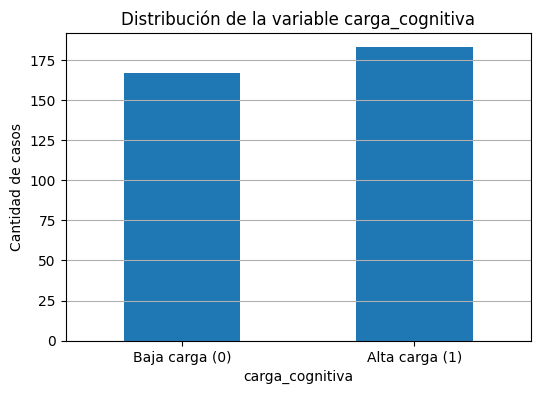

In [ ]:
plt.figure(figsize=(6, 4))
conteo_clases.plot(kind='bar')
plt.xticks([0, 1], ['Baja carga (0)', 'Alta carga (1)'], rotation=0)
plt.ylabel('Cantidad de casos')
plt.title('Distribución de la variable carga_cognitiva')
plt.grid(axis='y')
plt.show()

Ahora veremos algunos gráficos simples para explorar relaciones entre variables.

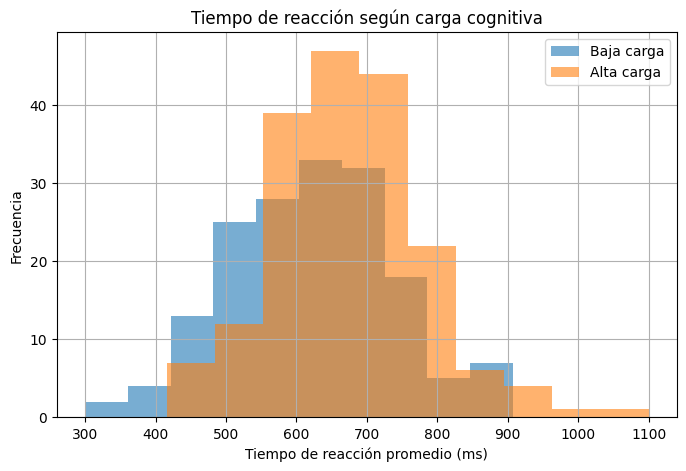

In [ ]:
plt.figure(figsize=(8, 5))

plt.hist(
    df[df['carga_cognitiva'] == 0]['tiempo_reaccion_ms'],
    alpha=0.6,
    label='Baja carga'
)

plt.hist(
    df[df['carga_cognitiva'] == 1]['tiempo_reaccion_ms'],
    alpha=0.6,
    label='Alta carga'
)

plt.xlabel('Tiempo de reacción promedio (ms)')
plt.ylabel('Frecuencia')
plt.title('Tiempo de reacción según carga cognitiva')
plt.legend()
plt.grid(True)
plt.show()

Este gráfico te ayuda a ver si la variable tiempo de reacción puede servir para predecir la carga cognitiva.

Y aquí parece que sí puede ayudar, porque los tiempos de reacción de alta carga tienden a ser más altos.

Pero como hay bastante mezcla, probablemente no baste solo con esta variable. El modelo puede mejorar si también usa otras variables, como precisión, fatiga, horas de sueño, nivel de atención, etc

Mientras más solapamiento haya, más difícil será para el modelo clasificar correctamente.

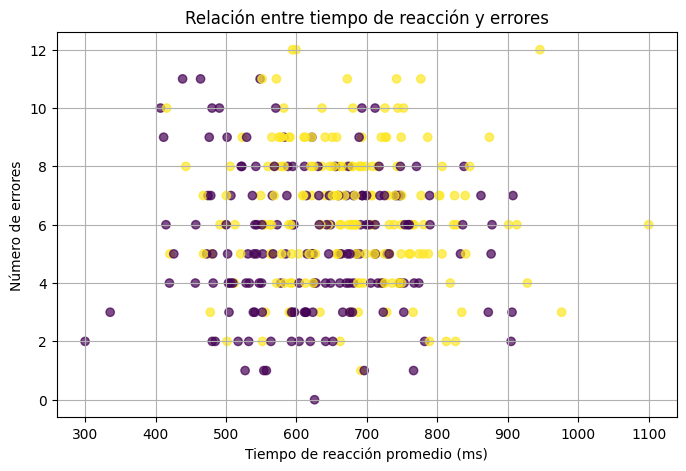

In [ ]:
plt.figure(figsize=(8, 5))

plt.scatter(
    df['tiempo_reaccion_ms'],
    df['errores'],
    c=df['carga_cognitiva'],
    alpha=0.7
)

plt.xlabel('Tiempo de reacción promedio (ms)')
plt.ylabel('Número de errores')
plt.title('Relación entre tiempo de reacción y errores')
plt.grid(True)
plt.show()

## ⚙️  3. Preparar los datos para scikit-learn

En `scikit-learn`, normalmente separamos los datos en:

- `X`: variables predictoras, es decir, las variables que usaremos para predecir.
- `y`: variable objetivo, es decir, lo que queremos predecir.

In [ ]:
from sklearn.model_selection import train_test_split

# Separamos predictoras (X) y variable objetivo (y)

# Variables predictoras
X = df[['tiempo_reaccion_ms', 'errores', 'horas_sueno', 'estres_percibido', 'precision']]

# Variable objetivo
y = df['carga_cognitiva']


Y luego dividimos los datos en dos partes:

- **Entrenamiento**: el modelo aprende con estos datos.
- **Prueba**: evaluamos si el modelo aprendió a **generalizar** (es decir, a desempeñarse bien con datos que nunca vio).


**Una analogía:**

> Si estudias con un conjunto de preguntas y luego te evalúan con exactamente las mismas preguntas, podrías memorizar. Pero si te evalúan con preguntas nuevas, se ve mejor si realmente entendiste.


In [ ]:
# Dividimos en entrenamiento (80%) y prueba (20%)
# stratify=y ayuda a mantener proporciones similares de clases en ambos grupos.

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Tamaño de X_train:", X_train.shape)
print("Tamaño de X_test:", X_test.shape)

Tamaño de X_train: (280, 5)
Tamaño de X_test: (70, 5)


El modelo estudia con el 80% de los datos y luego rinde un examen con el 20% que nunca vio.

## 📏 4: Escalar las variables

Tus variables tienen unidades distintas:

- tiempo de reacción: cientos de milisegundos;
- errores: números pequeños;
- horas de sueño: entre 2 y 10;
- estrés: de 1 a 10;
- precisión: porcentaje.

Para ayudar al modelo, vamos a escalar las variables con `StandardScaler`.

Escalar significa transformar las variables para que sean más comparables. No cambia la información central, pero ayuda a que el modelo trabaje mejor

In [ ]:
from sklearn.preprocessing import StandardScaler

# Creamos el escalador
scaler = StandardScaler()

# Ajustamos el escalador con los datos de entrenamiento
X_train_scaled = scaler.fit_transform(X_train)S

# Transformamos los datos de prueba usando el mismo escalador
X_test_scaled = scaler.transform(X_test)

print("Primeras 5 filas escaladas:")
print(X_train_scaled[:5])

Primeras 5 filas escaladas:
[[ 0.48618301 -0.32845966 -0.05068442  0.51485066  0.8973975 ]
 [ 0.18876992 -1.17609749 -0.28590492 -0.19880372 -0.12952328]
 [-1.59392239 -1.17609749 -2.32448257  1.58533222 -0.40877367]
 [ 1.64457576 -0.32845966  2.06630007  0.87167784 -0.28266059]
 [ 1.30250604  0.51917817 -0.36431175  1.58533222  1.56399521]]


## 🤖  5. Entrenar el modelo de regresión logística

La regresión logística aprenderá una combinación de pesos para las variables. Esos pesos ayudan a estimar la probabilidad de que un caso pertenezca a la clase `1`, es decir, **alta carga cognitiva**.

Conceptualmente, el modelo está buscando una forma de separar, lo mejor posible, los casos de baja y alta carga.

In [ ]:
from sklearn.linear_model import SGDClassifier

# Creamos el modelo usando Descenso de Gradiente (SGD)
modelo = SGDClassifier(
    loss='log_loss',             # Esto lo convierte en Regresión Logística
    learning_rate='constant',    # Mantiene la tasa de aprendizaje fija
    eta0=0.01,                   # Tasa de aprendizaje (alfa).
    max_iter=1000,               # Número máximo de iteraciones (épocas)
    tol=1e-3,                    # Criterio de parada
    random_state=42              # Para que los resultados sean reproducibles
)

# Entrenamos el modelo con los datos de entrenamiento escalados
modelo.fit(X_train_scaled, y_train)

print("✅ Modelo entrenado correctamente usando Descenso de Gradiente.")

# Ver los Betas encontrados (opcional, pero útil para ver qué encontró el optimizador)
print("Betas (Coeficientes):", modelo.coef_)
print("Beta 0 (Intercepto):", modelo.intercept_)

✅ Modelo entrenado correctamente usando Descenso de Gradiente.
Betas (Coeficientes): [[ 0.65063839  0.65786815 -0.6488904   0.79655327 -0.68159517]]
Beta 0 (Intercepto): [0.10983642]


**Significado de los resultados**:

[ 0.506839  0.6578615 -0.648890  0.7965327 -0.6819517 ]
- Cada beta corresponde a una variable.

Una beta positiva significa:

- “Cuando esta variable sube, aumenta la probabilidad de alta carga cognitiva.”

Una beta negativa significa:

-
“Cuando esta variable sube, disminuye la probabilidad de alta carga cognitiva.”

Beta 0 (Intercepto): [0.1098342]

Ese es el punto de partida del modelo antes de mirar las variables.


Y el descenso de gradiente es la forma en que el modelo va corrigiéndose poco a poco, como si dijera:

- “Me equivoqué un poco, ajusto mis pesos. Me volví a equivocar, ajusto otra vez. Repito hasta mejorar.”



## 🔮  6. Hacer predicciones

El modelo puede darnos dos tipos de salida:

- `predict`: devuelve la clase final, `0` o `1`.
- `predict_proba`: devuelve la **probabilidad** estimada para cada clase.


Por ejemplo, si el modelo estima una probabilidad de `0.78` para alta carga cognitiva, eso significa:

> El modelo estima un 78% de probabilidad de que ese caso pertenezca a la clase de alta carga cognitiva.

No significa que sea una **verdad absoluta**.


In [ ]:
# Clase predicha: 0 o 1
y_pred = modelo.predict(X_test_scaled)

# Probabilidades predichas
y_proba = modelo.predict_proba(X_test_scaled)

# Mostramos las primeras 10 predicciones
resultados = pd.DataFrame({
    'real': y_test.values,
    'predicho': y_pred,
    'prob_baja_carga': y_proba[:, 0].round(3),
    'prob_alta_carga': y_proba[:, 1].round(3)
})

resultados.head(10)

,real,predicho,prob_baja_carga,prob_alta_carga
0,1,1,0.090,0.910
1,1,1,0.222,0.778
2,1,0,0.867,0.133
3,0,1,0.243,0.757
4,1,1,0.320,0.680
5,1,1,0.085,0.915
6,1,1,0.443,0.557
7,0,0,0.847,0.153
8,1,1,0.098,0.902
9,0,1,0.157,0.843


### Umbral de decisión

Por defecto, el modelo usa un umbral de `0.5`.

- Si la probabilidad de alta carga es mayor o igual a `0.5`, predice `1`.
- Si la probabilidad es menor que `0.5`, predice `0`.

- **Importante**: Pero en problemas reales, el umbral podría cambiar según el costo de los errores.

---

## 📊 7. Evaluar el modelo

Evaluar un modelo significa preguntarnos:

> ¿Qué tan bien está prediciendo en datos que no usó para entrenar?

Usaremos tres herramientas:

1. **Accuracy:** porcentaje de predicciones correctas.
2. **Matriz de confusión:** tabla que muestra aciertos y errores.
3. **Classification report:** resumen con precision, recall y f1-score.

In [ ]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, ConfusionMatrixDisplay

# Accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy del modelo: {accuracy:.3f}")s

Accuracy del modelo: 0.729


De cada 100 personas nuevas, el modelo clasificaría correctamente a unas 73 como baja o alta carga cognitiva.

- Pero ojo: el accuracy no dice qué tipo de errores cometió. Por eso después se usa la matriz de confusión, para ver si se equivoca más con la clase 0 o con la clase 1.

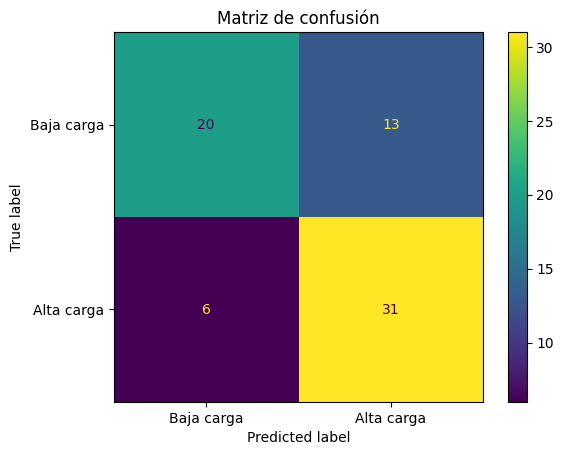

In [ ]:
# Matriz de confusión
cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=['Baja carga', 'Alta carga']
)

disp.plot()
plt.title('Matriz de confusión')
plt.show()

En simple:

- Había 33 personas con baja carga. El modelo acertó 20 y se equivocó en 13.
- Había 37 personas con alta carga. El modelo acertó 31 y se equivocó en 6.

Entonces:

- El modelo reconoce mejor los casos de alta carga cognitiva que los de baja carga cognitiva.

In [ ]:
# Reporte de clasificación
print(classification_report(y_test, y_pred, target_names=['Baja carga', 'Alta carga']))

              precision    recall  f1-score   support

  Baja carga       0.77      0.61      0.68        33
  Alta carga       0.70      0.84      0.77        37

    accuracy                           0.73        70
   macro avg       0.74      0.72      0.72        70
weighted avg       0.74      0.73      0.72        70



#### ¿Cómo interpretar la matriz de confusión?

La matriz de confusión compara lo real con lo predicho.

| Tipo de resultado | Significado en este ejercicio |
|---|---|
| Verdadero negativo | El caso era baja carga y el modelo predijo baja carga |
| Falso positivo | El caso era baja carga, pero el modelo predijo alta carga |
| Falso negativo | El caso era alta carga, pero el modelo predijo baja carga |
| Verdadero positivo | El caso era alta carga y el modelo predijo alta carga |

Por ejemplo:

- Un **falso positivo** podría hacer que interpretemos que alguien tiene alta carga cuando no la tiene.
- Un **falso negativo** podría hacer que no detectemos una posible alta carga cuando sí está presente


#### Métricas del classification report

- **Precision (precisión):** Cuando el modelo dice alta carga, ¿cuántas veces acierta?”
  - Alta carga: precision = 0.70 Cuando el modelo dijo “alta carga”, acertó el 70% de las veces.
  - Baja carga: precision = 0.77. Cuando el modelo dijo “baja carga”, acertó el 77% de las veces.

- **Recall (sensibilidad):**“De todos los casos que realmente eran alta carga, ¿cuántos logró encontrar?”
  - Significa que de todos los casos que realmente eran baja carga, el modelo solo detectó el 61%.
  - Significa que de todos los casos que realmente eran alta carga, el modelo detectó el 84%.
- **F1-score:** un equilibrio entre precision y recall.


---

## 🧩 8. Interpretar los coeficientes

Los coeficientes nos indican la dirección de la asociación entre cada variable y la probabilidad de alta carga cognitiva.

> 📌 **Cómo leerlos:**
>
> - **Coeficiente positivo** → aumenta la probabilidad de alta carga cognitiva.
> - **Coeficiente negativo** → la disminuye.
>
> ⚠️ **Estos coeficientes indican asociación dentro del dataset ficticio, no causalidad psicológica real.** Son una herramienta descriptiva del modelo, no una conclusión teórica sobre la cognición humana.

             Variable  Coeficiente
3    estres_percibido     0.796553
1             errores     0.657868
0  tiempo_reaccion_ms     0.650638
2         horas_sueno    -0.648890
4           precision    -0.681595


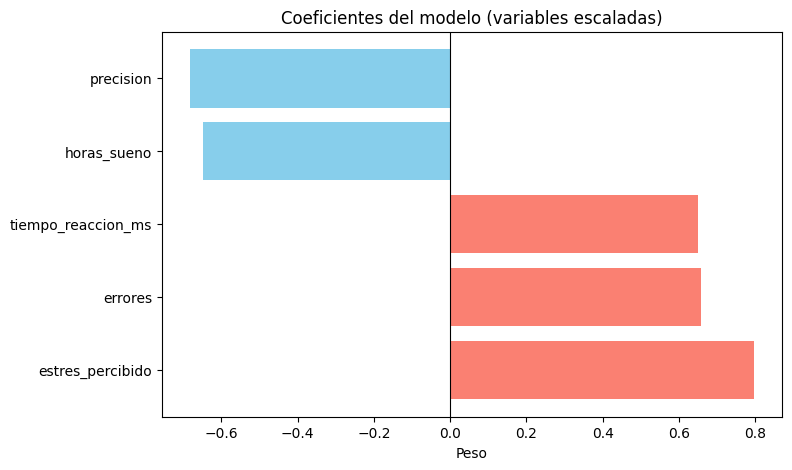

In [ ]:
coeficientes = pd.DataFrame({
    'Variable': X.columns,
    'Coeficiente': modelo.coef_[0]
}).sort_values('Coeficiente', ascending=False)

print(coeficientes)

plt.figure(figsize=(8, 5))
plt.barh(coeficientes['Variable'], coeficientes['Coeficiente'],
         color=['salmon' if c > 0 else 'skyblue' for c in coeficientes['Coeficiente']])
plt.axvline(0, color='black', linewidth=0.8)
plt.title('Coeficientes del modelo (variables escaladas)')
plt.xlabel('Peso')
plt.show()

- El modelo aprendió que una persona con más estrés, más errores y reacción más lenta tiende a parecerse más a alguien con alta carga cognitiva.

- Una persona con más sueño y más precisión tiende a parecerse menos a alguien con alta carga cognitiva.

## 🎮 9. Sección interactiva — modifica un participante ficticio

Ahora crearemos una función para que puedas modificar los valores de un participante ficticio.

La función recibirá:

- tiempo de reacción;
- errores;
- horas de sueño;
- estrés percibido;
- precisión.

Luego devolverá:

- probabilidad de alta carga cognitiva;
- clase predicha.

In [ ]:
def predecir_carga(tiempo_reaccion_ms, errores, horas_sueno, estres_percibido, precision):
    """
    Predice la probabilidad de alta carga cognitiva para un caso ficticio.
    """

    nuevo_caso = pd.DataFrame({
        'tiempo_reaccion_ms': [tiempo_reaccion_ms],
        'errores': [errores],
        'horas_sueno': [horas_sueno],
        'estres_percibido': [estres_percibido],
        'precision': [precision]
    })

    # Escalamos usando el mismo scaler entrenado antes
    nuevo_caso_scaled = scaler.transform(nuevo_caso)

    # Probabilidad de clase 1 = alta carga
    probabilidad = modelo.predict_proba(nuevo_caso_scaled)[0][1]

    # Clase predicha
    clase = modelo.predict(nuevo_caso_scaled)[0]

    print("Valores del participante ficticio:")
    display(nuevo_caso)

    print(f"🔢 Probabilidad de alta carga cognitiva: {probabilidad:.2f}")

    if clase == 1:
        print("🔴 Predicción del modelo: ALTA carga cognitiva")
    else:
        print("🟢 Predicción del modelo: BAJA carga cognitiva")

Probemos con un participante ficticio que tiene señales de posible alta carga.

In [ ]:
predecir_carga(
    tiempo_reaccion_ms=850,
    errores=12,
    horas_sueno=4,
    estres_percibido=8,
    precision=60
)

Valores del participante ficticio:


,tiempo_reaccion_ms,errores,horas_sueno,estres_percibido,precision
0,850,12,4,8,60


🔢 Probabilidad de alta carga cognitiva: 1.00
🔴 Predicción del modelo: ALTA carga cognitiva


Ahora probemos con un participante ficticio que tiene señales de menor carga.

In [ ]:
predecir_carga(
    tiempo_reaccion_ms=500,
    errores=2,
    horas_sueno=8,
    estres_percibido=3,
    precision=90
)

Valores del participante ficticio:


,tiempo_reaccion_ms,errores,horas_sueno,estres_percibido,precision
0,500,2,8,3,90


🔢 Probabilidad de alta carga cognitiva: 0.01
🟢 Predicción del modelo: BAJA carga cognitiva


## 10. Versión opcional con sliders en Google Colab

In [ ]:
try:
    import ipywidgets as widgets
    from IPython.display import display, clear_output

    slider_tiempo = widgets.IntSlider(
        value=650, min=300, max=1100, step=10,
        description='Tiempo ms:'
    )

    slider_errores = widgets.IntSlider(
        value=6, min=0, max=20, step=1,
        description='Errores:'
    )

    slider_sueno = widgets.FloatSlider(
        value=6.5, min=2, max=10, step=0.5,
        description='Sueño:'
    )

    slider_estres = widgets.IntSlider(
        value=5, min=1, max=10, step=1,
        description='Estrés:'
    )

    slider_precision = widgets.IntSlider(
        value=75, min=30, max=100, step=1,
        description='Precisión:'
    )

    salida = widgets.Output()

    def actualizar_prediccion(change=None):
        with salida:
            clear_output()
            predecir_carga(
                tiempo_reaccion_ms=slider_tiempo.value,
                errores=slider_errores.value,
                horas_sueno=slider_sueno.value,
                estres_percibido=slider_estres.value,
                precision=slider_precision.value
            )

    for slider in [slider_tiempo, slider_errores, slider_sueno, slider_estres, slider_precision]:
        slider.observe(actualizar_prediccion, names='value')

    display(slider_tiempo, slider_errores, slider_sueno, slider_estres, slider_precision, salida)
    actualizar_prediccion()

except Exception as e:
    print("No se pudieron cargar los widgets en este entorno.")
    print("Puedes usar la función predecir_carga() de la sección anterior.")
    print("Error:", e)

IntSlider(value=650, description='Tiempo ms:', max=1100, min=300, step=10)

IntSlider(value=6, description='Errores:', max=20)

FloatSlider(value=6.5, description='Sueño:', max=10.0, min=2.0, step=0.5)

IntSlider(value=5, description='Estrés:', max=10, min=1)

IntSlider(value=75, description='Precisión:', min=30)

Output()

### 🗺 18. Frontera de decisión simple


El modelo original usa cinco variables, por eso no podemos visualizarlo fácilmente en dos dimensiones.

Para entender la idea de **frontera de decisión**, entrenaremos un segundo modelo usando solo dos variables:

- `tiempo_reaccion_ms`
- `errores`

Esto es una simplificación didáctica.

La frontera de decisión es la línea o zona que separa los casos que el modelo tiende a clasificar como baja carga de aquellos que tiende a clasificar como alta carga.

In [ ]:
# Elegimos solo dos variables
X_2 = df[['tiempo_reaccion_ms', 'errores']]
y_2 = df['carga_cognitiva']

# Dividimos datos
X2_train, X2_test, y2_train, y2_test = train_test_split(
    X_2,
    y_2,
    test_size=0.25,
    random_state=42,
    stratify=y_2
)

# Escalamos
scaler_2 = StandardScaler()
X2_train_scaled = scaler_2.fit_transform(X2_train)
X2_test_scaled = scaler_2.transform(X2_test)

# Entrenamos modelo simplificado
modelo_2 = SGDClassifier(
    loss='log_loss',
    learning_rate='constant',
    eta0=0.01,
    max_iter=1000,
    tol=1e-3,
    random_state=42
)
modelo_2.fit(X2_train_scaled, y2_train)

print("Modelo simplificado entrenado con dos variables.")

Modelo simplificado entrenado con dos variables.


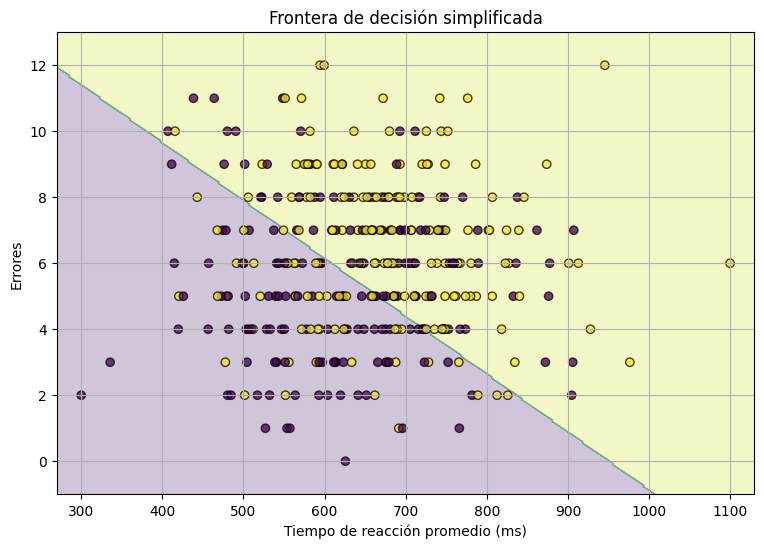

In [ ]:
# Creamos una malla de puntos para graficar regiones de decisión
x_min, x_max = X_2['tiempo_reaccion_ms'].min() - 30, X_2['tiempo_reaccion_ms'].max() + 30
y_min, y_max = X_2['errores'].min() - 1, X_2['errores'].max() + 1

xx, yy = np.meshgrid(
    np.linspace(x_min, x_max, 300),
    np.linspace(y_min, y_max, 300)
)

malla = pd.DataFrame({
    'tiempo_reaccion_ms': xx.ravel(),
    'errores': yy.ravel()
})

malla_scaled = scaler_2.transform(malla)
Z = modelo_2.predict(malla_scaled)
Z = Z.reshape(xx.shape)

plt.figure(figsize=(9, 6))
plt.contourf(xx, yy, Z, alpha=0.25)

plt.scatter(
    X_2['tiempo_reaccion_ms'],
    X_2['errores'],
    c=y_2,
    alpha=0.75,
    edgecolor='k'
)

plt.xlabel('Tiempo de reacción promedio (ms)')
plt.ylabel('Errores')
plt.title('Frontera de decisión simplificada')
plt.grid(True)
plt.show()

> 🧭 La **frontera de decisión** es la zona que separa los casos que el modelo tiende a clasificar como baja carga de los que tiende a clasificar como alta carga. Como ves, no es perfecta: hay solapamiento, igual que en datos reales.

---

# 20. Overfitting, generalización y regularización

## Overfitting

El **overfitting** (o sobreajuste) ocurre cuando un modelo aprende demasiado bien los detalles específicos de los datos de entrenamiento, incluyendo el ruido o patrones accidentales.

En palabras simples:

> El modelo memoriza los datos en lugar de aprender una regla general.

## Generalización

La **generalización** ocurre cuando el modelo funciona bien con datos nuevos y desconocidos.

Esto es lo que realmente nos interesa lograr al entrenar un modelo.

## Regularización

La **regularización** es una técnica matemática que ayuda a evitar el overfitting. Funciona imponiendo un "castigo" o "multa" al modelo durante el entrenamiento para evitar que los coeficientes (los Betas) crezcan demasiado o dependan en exceso de ciertas variables.

Existen diferentes tipos de regularización, pero nosotros estamos usando la **Regularización L2 (también conocida como Ridge)**.
La técnica L2 aplica una multa proporcional al *cuadrado* del tamaño de los coeficientes. Esto obliga al algoritmo (Descenso de Gradiente) a mantener todos los Betas pequeños y balanceados, evitando que una sola variable domine por completo la predicción.

Al optimizar con `SGDClassifier`, controlamos la fuerza de esta multa mediante el parámetro `alpha`:

- **`alpha` grande** (ej. `0.1`) → **Más regularización (multa alta)**. Encoge fuertemente los Betas hacia cero, forzando un modelo más simple y general.
- **`alpha` pequeño** (ej. `0.0001`) → **Menos regularización (multa baja)**. Permite que el modelo ajuste sus Betas más libremente a los datos de entrenamiento.

In [ ]:
# Modelo con más regularización (alpha alto = mayor penalización a los betas)
modelo_mas_regularizado = SGDClassifier(
    loss='log_loss',
    penalty='l2',                # Especificamos regularización tipo Ridge (L2)
    alpha=0.1,                   # ALPHA ALTO = Más regularización
    learning_rate='constant',
    eta0=0.01,
    max_iter=1000,
    random_state=42
)
modelo_mas_regularizado.fit(X_train_scaled, y_train)
pred_mas_reg = modelo_mas_regularizado.predict(X_test_scaled)

# Modelo con menos regularización (alpha bajo = menor penalización a los betas)
modelo_menos_regularizado = SGDClassifier(
    loss='log_loss',
    penalty='l2',
    alpha=0.0001,                # ALPHA BAJO = Menos regularización
    learning_rate='constant',
    eta0=0.01,
    max_iter=1000,
    random_state=42
)
modelo_menos_regularizado.fit(X_train_scaled, y_train)
pred_menos_reg = modelo_menos_regularizado.predict(X_test_scaled)

print("Accuracy con más regularización, alpha=0.1:", round(accuracy_score(y_test, pred_mas_reg), 3))
print("Accuracy con menos regularización, alpha=0.0001:", round(accuracy_score(y_test, pred_menos_reg), 3))

Accuracy con más regularización, alpha=0.1: 0.714
Accuracy con menos regularización, alpha=0.0001: 0.729


In [ ]:
comparacion_coeficientes = pd.DataFrame({
    'variable': X.columns,
    'coef_C_0.1_mas_regularizacion': modelo_mas_regularizado.coef_[0],
    'coef_C_1_modelo_original': modelo.coef_[0],
    'coef_C_10_menos_regularizacion': modelo_menos_regularizado.coef_[0]
})

comparacion_coeficientes

,variable,coef_C_0.1_mas_regularizacion,coef_C_1_modelo_original,coef_C_10_menos_regularizacion
0,tiempo_reaccion_ms,0.364736,0.650638,0.650638
1,errores,0.360956,0.657868,0.657868
2,horas_sueno,-0.380352,-0.648890,-0.648890
3,estres_percibido,0.462965,0.796553,0.796553
4,precision,-0.389997,-0.681595,-0.681595


# 🧠 Ejercicio  práctico — Regresión Logística aplicada a Psicología

## Caso de estudio: Predicción del **riesgo de ansiedad social** en estudiantes universitarios

En este ejercicio guiado aplicarás un modelo de **Regresión Logística** para predecir si un estudiante presenta o no **riesgo elevado de ansiedad social**, a partir de variables conductuales y cognitivas medidas en un experimento ficticio.

-
---

### 📋 Reglas del ejercicio
- 🟡 Cada bloque tiene una sección **"Tu tarea"** donde debes completar código (`# TODO`).
- 💭 Cada paso incluye preguntas de **reflexión** — respóndelas en las celdas de texto.
- ❌ **No copies y pegues sin entender**. El objetivo es que sepas explicar qué hace cada línea.
- ✅ Si te atascas, lee la pista 💡 y consulta la documentación de `scikit-learn`.

¡Comencemos! 🚀


## 📖 1. Contexto del problema

La **ansiedad social** es un trastorno frecuente entre estudiantes universitarios. Detectarla tempranamente puede ayudar a derivar a los estudiantes a servicios de apoyo psicológico.

En este taller trabajaremos con un dataset **ficticio** que simula medidas tomadas a 400 estudiantes durante una evaluación de laboratorio. Las variables son:

| Variable | Descripción | Tipo |
|---|---|---|
| `frecuencia_cardiaca` | Frecuencia cardíaca media (lpm) durante una tarea de habla en público simulada | numérica |
| `evitacion_contacto_visual` | Número de veces que el participante evitó la cámara en 5 min | numérica (0–30) |
| `horas_redes_sociales` | Horas diarias promedio en redes sociales | numérica |
| `autoestima` | Puntaje en escala de Rosenberg (10–40) | numérica |
| `rumiacion_cognitiva` | Puntaje en escala de rumiación (1–10) | numérica |
| `riesgo_ansiedad_social` | **Variable objetivo**: 1 = riesgo elevado, 0 = riesgo bajo | binaria |

> 🧠 **Pregunta de calentamiento**: Antes de tocar código, ¿qué relación esperarías entre `autoestima` y el `riesgo_ansiedad_social`? ¿Y entre `rumiacion_cognitiva` y el riesgo?  
> *Escribe tu hipótesis abajo antes de avanzar.*


**✍️ Tu hipótesis (antes de ver los datos):**

> *Escribe aquí tus expectativas...*


## 🧪 2. Creación del dataset ficticio

En esta sección **ya te entregamos los valores ficticios listos**. Tu tarea es **leer el código y entender** qué tipo de distribución se usa para cada variable y por qué.

> 💭 **Reflexiona**: ¿Por qué usamos `np.random.normal` para frecuencia cardíaca y `np.random.poisson` para conteos? ¿Qué ocurriría si invirtiéramos las distribuciones?


In [ ]:
# 📦 Importamos las librerías base
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Fijamos una semilla para que los resultados sean reproducibles
np.random.seed(123)

# Número de observaciones ficticias
n = 400

# 🎲 Variables ficticias (¡valores entregados!)
frecuencia_cardiaca       = np.random.normal(loc=85, scale=12, size=n)
evitacion_contacto_visual = np.random.poisson(lam=8, size=n)
horas_redes_sociales      = np.random.normal(loc=4.5, scale=1.8, size=n)
autoestima                = np.random.normal(loc=28, scale=6, size=n)
rumiacion_cognitiva       = np.random.randint(1, 11, size=n)

# Ajustamos límites razonables (clipping)
frecuencia_cardiaca       = np.clip(frecuencia_cardiaca, 55, 130)
evitacion_contacto_visual = np.clip(evitacion_contacto_visual, 0, 30)
horas_redes_sociales      = np.clip(horas_redes_sociales, 0, 12)
autoestima                = np.clip(autoestima, 10, 40)


### 🛠️ Tu tarea 2.1 — Generar la variable objetivo

Ahora debes **construir tú mismo/a la variable objetivo `riesgo_ansiedad_social`** siguiendo la lógica que se te indica.

**Lógica del fenómeno (basada en literatura psicológica):**
- ⬆️ Más frecuencia cardíaca, evitación visual, horas en redes y rumiación → **aumentan** el riesgo.
- ⬇️ Más autoestima → **disminuye** el riesgo.

💡 **Pista**: Sigue la estructura `z = pesoA * (varA - centroA) + pesoB * (varB - centroB) - pesoC * (varC - centroC) ...`

⚠️ Recuerda: el signo del coeficiente determina si la variable **aumenta** o **disminuye** el riesgo.


In [ ]:
# 🛠️ TODO: Construye la puntuación interna 'z' siguiendo la lógica indicada arriba.
# Sugerencia de pesos (puedes ajustar luego para experimentar):
#   frecuencia_cardiaca       -> peso 0.05  (centro 85)
#   evitacion_contacto_visual -> peso 0.30  (centro 8)
#   horas_redes_sociales      -> peso 0.25  (centro 4.5)
#   autoestima                -> peso -0.15 (centro 28)   ← signo negativo
#   rumiacion_cognitiva       -> peso 0.40  (centro 5)

# z = ...   # ← completa esta línea

# Agregamos ruido para que el dataset no sea perfecto
# ruido = np.random.normal(0, 0.8, size=n)
# z = z + ruido

# 🛠️ TODO: Convierte z en probabilidad usando la función sigmoide
#          probabilidad = 1 / (1 + e^(-z))
# probabilidad_riesgo = ...

# 🛠️ TODO: Genera la variable binaria con np.random.binomial
# riesgo_ansiedad_social = ...


### 🛠️ Tu tarea 2.2 — Construir el DataFrame

Una vez generadas las variables, organízalas en un `pd.DataFrame` con las columnas en este orden:

`frecuencia_cardiaca, evitacion_contacto_visual, horas_redes_sociales, autoestima, rumiacion_cognitiva, riesgo_ansiedad_social`


In [ ]:
# 🛠️ TODO: Crea el DataFrame 'df' con todas las variables.
# Recuerda redondear las variables continuas a 1 decimal con .round(1)

# df = pd.DataFrame({
#     'frecuencia_cardiaca': ...,
#     'evitacion_contacto_visual': ...,
#     ...
# })

# Mostramos las primeras filas
# df.head()


## 🔍 3. Exploración del dataset (EDA)

Antes de modelar, **siempre** debemos conocer nuestros datos. Esto se llama *Análisis Exploratorio de Datos (EDA)*.

> 💭 **Reflexiona**: ¿Por qué es peligroso entrenar un modelo sin haber explorado los datos primero? Piensa en sesgos, datos faltantes, desbalance de clases…


In [ ]:
# 🛠️ TODO: Imprime las dimensiones del dataset (filas, columnas)
# print("Filas y columnas:", ...)

# 🛠️ TODO: Muestra los estadísticos descriptivos del DataFrame
# df.describe()


### 3.1 Distribución de la variable objetivo

¿Está balanceada la cantidad de casos con riesgo alto vs bajo? Esto es **crítico** porque un dataset desbalanceado puede sesgar el modelo.


In [ ]:
# 🛠️ TODO: Cuenta cuántos casos hay en cada clase (0 y 1)
# Usa value_counts() y ordena por índice
# conteo_clases = ...
# print(conteo_clases)


In [ ]:
# 🛠️ TODO: Grafica la distribución de clases en un gráfico de barras.
# Sugerencia de pasos:
#   1. plt.figure(figsize=(6, 4))
#   2. conteo_clases.plot(kind='bar')
#   3. plt.xticks([0, 1], ['Riesgo bajo (0)', 'Riesgo alto (1)'], rotation=0)
#   4. Añade ylabel, title y plt.grid(axis='y')
#   5. plt.show()


**💭 Pregunta:** Si el conteo fuera 350 vs 50, ¿qué problema tendría tu modelo? ¿Qué técnicas conoces para manejar datos desbalanceados?

> *Tu respuesta:*


### 3.2 Histograma de una variable continua según el riesgo

Compararemos cómo se distribuye la **autoestima** entre los dos grupos (riesgo alto vs bajo).


In [ ]:
# 🛠️ TODO: Dibuja dos histogramas superpuestos de 'autoestima'
# uno para riesgo bajo (0) y otro para riesgo alto (1).
# Pista:
#   plt.hist(df[df['riesgo_ansiedad_social'] == 0]['autoestima'], alpha=0.6, label='Riesgo bajo')
#   plt.hist(df[df['riesgo_ansiedad_social'] == 1]['autoestima'], alpha=0.6, label='Riesgo alto')
# Recuerda añadir xlabel, ylabel, title, legend, grid y show.


### 3.3 Diagrama de dispersión

Visualicemos la relación entre **rumiación cognitiva** y **evitación visual**, coloreando por la clase objetivo.


In [ ]:
# 🛠️ TODO: Construye un scatter plot con:
#   - eje X: rumiacion_cognitiva
#   - eje Y: evitacion_contacto_visual
#   - color (c): riesgo_ansiedad_social
# Añade etiquetas, título y plt.show()


**💭 Pregunta:** ¿Se observa algún patrón visual? ¿Las clases están bien separadas o hay solapamiento? ¿Qué implica esto para la tarea de clasificación?


## 🧰 4. Preparación de los datos

Antes de entrenar, debemos:

1. **Separar** las variables predictoras (X) de la variable objetivo (y).
2. **Dividir** el dataset en entrenamiento (train) y prueba (test).
3. **Escalar** las variables para que estén en escalas comparables.

> 💭 **Reflexiona**: ¿Por qué separamos los datos de prueba *antes* de escalar? ¿Qué problema causaría escalar todo junto? (Pista: *data leakage*)


In [ ]:
from sklearn.model_selection import train_test_split

# 🛠️ TODO: Define X (predictoras) e y (objetivo)
# X = df[[ ... lista de columnas predictoras ... ]]
# y = df['riesgo_ansiedad_social']

# 🛠️ TODO: Divide en train (80%) y test (20%) con stratify=y
# X_train, X_test, y_train, y_test = train_test_split(...)

# print("Tamaño de X_train:", X_train.shape)
# print("Tamaño de X_test :", X_test.shape)


### 4.1 Escalado de variables

`StandardScaler` transforma cada variable para que tenga media 0 y desviación estándar 1.


In [ ]:
from sklearn.preprocessing import StandardScaler

# 🛠️ TODO: Crea el escalador
# scaler = StandardScaler()

# 🛠️ TODO: Ajusta y transforma los datos de ENTRENAMIENTO
# X_train_scaled = scaler.fit_transform(X_train)

# 🛠️ TODO: Transforma los datos de PRUEBA con el mismo escalador
# (¡OJO! Aquí solo .transform(), NO .fit_transform())
# X_test_scaled = scaler.transform(X_test)

# print("Primeras 5 filas escaladas:")
# print(X_train_scaled[:5])


**💭 Pregunta crítica:** ¿Por qué en train usamos `fit_transform` pero en test solo `transform`? ¿Qué pasaría si usáramos `fit_transform` en ambos?

> *Tu respuesta:*


## 🤖 5. Entrenamiento del modelo

Usaremos la clase `LogisticRegression` de scikit-learn.

> 📚 **Recordatorio teórico**: La regresión logística modela la probabilidad de pertenecer a la clase 1 mediante:
>
> $$P(y=1 \mid X) = \frac{1}{1 + e^{-(\beta_0 + \beta_1 x_1 + \beta_2 x_2 + ... + \beta_n x_n)}}$$


In [ ]:
from sklearn.linear_model import LogisticRegression

# 🛠️ TODO: Crea el modelo con random_state=42
# modelo = ...

# 🛠️ TODO: Entrena con los datos de entrenamiento ESCALADOS
# modelo.fit(...)

# print("✅ Modelo entrenado correctamente.")


## 🔮 6. Predicciones sobre el conjunto de prueba

Generaremos dos tipos de predicciones:
- **Clase predicha** (0 o 1) → `.predict()`
- **Probabilidad de cada clase** → `.predict_proba()`


In [ ]:
# 🛠️ TODO: Genera las clases predichas para X_test_scaled
# y_pred = ...

# 🛠️ TODO: Genera las probabilidades predichas
# y_proba = ...

# 🛠️ TODO: Crea un DataFrame 'resultados' con las columnas:
# - 'real':              valores reales (y_test.values)
# - 'predicho':          y_pred
# - 'prob_riesgo_bajo':  y_proba[:, 0].round(3)
# - 'prob_riesgo_alto':  y_proba[:, 1].round(3)
# Muestra las primeras 10 filas.


**💭 Pregunta:** Observa los casos donde `real != predicho`. ¿Las probabilidades son cercanas a 0.5 (modelo dudaba) o muy alejadas (modelo se equivocó con confianza)? ¿Qué implica esto?


## 📊 7. Evaluación del modelo

Evaluaremos el modelo con tres herramientas:
1. **Accuracy** — proporción de aciertos.
2. **Matriz de confusión** — desglose de aciertos y errores por clase.
3. **Classification report** — precision, recall y F1.

> 💭 **Reflexiona**: En un contexto de salud mental, ¿qué es peor: un **falso positivo** (predecir riesgo alto cuando no lo hay) o un **falso negativo** (no detectar a alguien en riesgo)? ¿Por qué?


In [ ]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, ConfusionMatrixDisplay

# 🛠️ TODO: Calcula e imprime el accuracy
# accuracy = ...
# print(f"Accuracy del modelo: {accuracy:.3f}")


In [ ]:
# 🛠️ TODO: Calcula la matriz de confusión y muéstrala con ConfusionMatrixDisplay
# cm = ...
# disp = ConfusionMatrixDisplay(confusion_matrix=cm,
#                                display_labels=['Riesgo bajo', 'Riesgo alto'])
# disp.plot()
# plt.title('Matriz de confusión')
# plt.show()


In [ ]:
# 🛠️ TODO: Imprime el classification_report
# print(classification_report(y_test, y_pred, target_names=['Riesgo bajo', 'Riesgo alto']))


**💭 Interpreta los resultados:**

- ¿Cuál es el valor de **recall** para la clase "Riesgo alto"? ¿Es aceptable en un contexto clínico?
- ¿Hay diferencias importantes entre **precision** y **recall**? ¿Qué significa eso?

> *Tu interpretación:*


## 🧠 8. Interpretación de coeficientes

Una de las grandes ventajas de la regresión logística es que es **interpretable**. Cada variable tiene un coeficiente que indica:
- **Signo (+/-)**: dirección del efecto.
- **Magnitud**: importancia relativa (con variables escaladas).


In [ ]:
# 🛠️ TODO: Construye un DataFrame con dos columnas:
# - 'Variable':     X.columns
# - 'Coeficiente':  modelo.coef_[0]
# Ordénalo descendentemente por 'Coeficiente'.
# coeficientes = ...
# print(coeficientes)


In [ ]:
# 🛠️ TODO: Grafica los coeficientes en un gráfico de barras horizontales.
# Usa color salmon para coeficientes positivos y skyblue para negativos.
# Pista:
#   plt.barh(coeficientes['Variable'], coeficientes['Coeficiente'],
#            color=['salmon' if c > 0 else 'skyblue' for c in coeficientes['Coeficiente']])
#   plt.axvline(0, color='black', linewidth=0.8)


**💭 Interpretación psicológica:**

1. ¿Cuál fue la variable con **mayor peso positivo**? ¿Tiene sentido desde la teoría psicológica?
2. ¿Algún coeficiente fue **contrario a tu hipótesis inicial**? ¿Por qué crees que ocurrió?
3. ¿Coinciden los signos con la lógica que usaste para generar `z` en la sección 2?

> *Tu interpretación:*


## 🧑‍🔬 9. Predicción sobre nuevos participantes ficticios

Crearemos una función que permita predecir el riesgo para un estudiante hipotético.


In [ ]:
# 🛠️ TODO: Completa esta función paso a paso.

def predecir_riesgo(frecuencia_cardiaca, evitacion_contacto_visual,
                    horas_redes_sociales, autoestima, rumiacion_cognitiva):
    """
    Predice la probabilidad de riesgo de ansiedad social para un caso ficticio.
    """

    # 🛠️ TODO: Crea un DataFrame 'nuevo_caso' con una sola fila
    # nuevo_caso = pd.DataFrame({...})

    # 🛠️ TODO: Escala el nuevo caso usando el mismo scaler entrenado antes
    # nuevo_caso_scaled = ...

    # 🛠️ TODO: Calcula la probabilidad de la clase 1 (riesgo alto)
    # probabilidad = ...

    # 🛠️ TODO: Calcula la clase predicha (0 o 1)
    # clase = ...

    # print("Valores del participante ficticio:")
    # display(nuevo_caso)
    # print(f"🔢 Probabilidad de riesgo alto: {probabilidad:.2f}")

    # if clase == 1:
    #     print("🔴 Predicción del modelo: RIESGO ALTO de ansiedad social")
    # else:
    #     print("🟢 Predicción del modelo: RIESGO BAJO de ansiedad social")

    pass  # ← elimina esto cuando completes la función


### 9.1 Pruébalo con dos casos contrastantes

**Caso A — Perfil con muchos indicadores de riesgo:**


In [ ]:
# 🛠️ TODO: Llama a predecir_riesgo con valores que sugieran riesgo alto
# predecir_riesgo(
#     frecuencia_cardiaca=110,
#     evitacion_contacto_visual=20,
#     horas_redes_sociales=8,
#     autoestima=15,
#     rumiacion_cognitiva=9
# )


**Caso B — Perfil con bajo indicador de riesgo:**


In [ ]:
# 🛠️ TODO: Llama a predecir_riesgo con valores que sugieran riesgo bajo
# predecir_riesgo(
#     frecuencia_cardiaca=70,
#     evitacion_contacto_visual=2,
#     horas_redes_sociales=1.5,
#     autoestima=36,
#     rumiacion_cognitiva=2
# )


### 9.2 🚀 Reto opcional: interfaz interactiva con sliders

Si terminaste todo lo anterior, intenta construir una interfaz con `ipywidgets` que permita mover sliders y ver la predicción en tiempo real.

💡 **Pista**: necesitas `IntSlider`, `FloatSlider`, un `Output` y un `observe` para detectar cambios.


In [ ]:
# 🛠️ Reto: implementa la interfaz interactiva (basada en lo visto en clase)
# import ipywidgets as widgets
# from IPython.display import display, clear_output
# ...
